# FER-CE ViT Baseline (Kaggle Version)

**Dataset**: [raf-ce-2026](https://www.kaggle.com/datasets/raf-ce-2026)

Vision Transformer implementation with data analysis and comprehensive metrics.

In [1]:
import os
import sys
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import models, transforms
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np
from PIL import Image

# Kaggle paths
KAGGLE_INPUT = '/kaggle/input/raf-ce-2026'
IMG_DIR = os.path.join(KAGGLE_INPUT, 'aligned/aligned')
LABEL_FILE = os.path.join(KAGGLE_INPUT, 'RAFCE_emolabel.txt')
PARTITION_FILE = os.path.join(KAGGLE_INPUT, 'RAFCE_partition.txt')
OUTPUT_DIR = '/kaggle/working/vit_outputs'

os.makedirs(OUTPUT_DIR, exist_ok=True)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {DEVICE}")

Using device: cuda


In [2]:
EMO_MAP = {
    0: "Happily surprised", 1: "Happily disgusted", 2: "Sadly fearful", 3: "Sadly angry",
    4: "Sadly surprised", 5: "Sadly disgusted", 6: "Fearfully angry", 7: "Fearfully surprised",
    8: "Fearfully disgusted", 9: "Angrily surprised", 10: "Angrily disgusted",
    11: "Disgustedly surprised", 12: "Happily fearful", 13: "Happily sad"
}

## Dataset Class

In [3]:
class RAFCEDataset(Dataset):
    def __init__(self, root_dir, label_file, partition_file, split=1, transform=None):
        self.root_dir = root_dir
        self.transform = transform
        
        labels_df = pd.read_csv(label_file, sep=' ', header=None, names=['image_name', 'label'])
        partition_df = pd.read_csv(partition_file, sep=' ', header=None, names=['image_name', 'split'])
        
        merged = labels_df.merge(partition_df, on='image_name')
        self.data = merged[merged['split'] == split].reset_index(drop=True)
    
    def __len__(self):
        return len(self.data)
    
    def __getitem__(self, idx):
        img_name = self.data.iloc[idx, 0]
        base_name = img_name.split('.')[0]
        full_img_name = f"{base_name}_aligned.jpg"
        img_path = os.path.join(self.root_dir, full_img_name)
        
        image = Image.open(img_path).convert('RGB')
        label = int(self.data.iloc[idx, 1])
        
        if self.transform:
            image = self.transform(image)
        
        return image, label

def get_transforms(augment=False):
    if augment:
        return transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.RandomHorizontalFlip(),
            transforms.RandomRotation(10),
            transforms.ColorJitter(brightness=0.2, contrast=0.2),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])
    else:
        return transforms.Compose([
            transforms.Resize((224, 224)),
            transforms.ToTensor(),
            transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
        ])

## Data Analysis

/tmp/ipykernel_55/2200866112.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='emotion', order=df['emotion'].value_counts().index, palette='viridis')


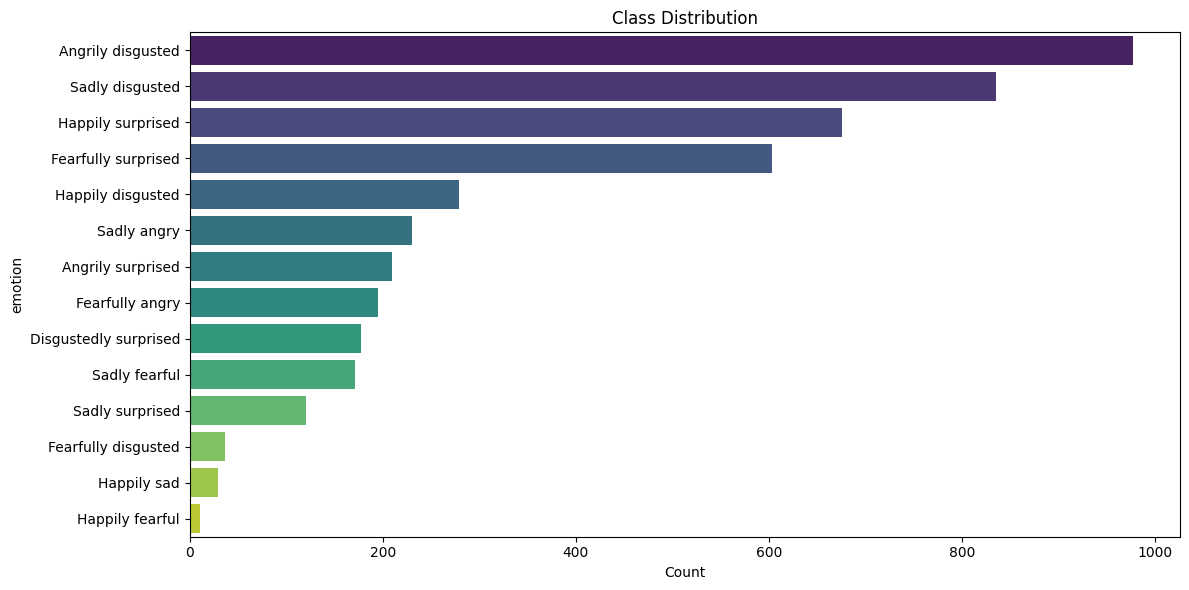

Total: 4549
emotion
Angrily disgusted    977
Sadly disgusted      835
Happily surprised    676
Name: count, dtype: int64


In [4]:
df = pd.read_csv(LABEL_FILE, sep=' ', header=None, names=['image_name', 'label'])
df['emotion'] = df['label'].map(EMO_MAP)

plt.figure(figsize=(12, 6))
sns.countplot(data=df, y='emotion', order=df['emotion'].value_counts().index, palette='viridis')
plt.title('Class Distribution')
plt.xlabel('Count')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'class_distribution.png'))
plt.show()

print(f"Total: {len(df)}")
print(df['emotion'].value_counts().head(3))

## Data Loading

In [5]:
BATCH_SIZE = 16
EPOCHS = 15
LR = 1e-4
NUM_CLASSES = 14

train_transform = get_transforms(augment=True)
val_transform = get_transforms(augment=False)

train_dataset = RAFCEDataset(IMG_DIR, LABEL_FILE, PARTITION_FILE, split=1, transform=train_transform)
test_dataset = RAFCEDataset(IMG_DIR, LABEL_FILE, PARTITION_FILE, split=2, transform=val_transform)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train: {len(train_dataset)}, Test: {len(test_dataset)}")

Train: 909, Test: 931


## ViT Model

In [6]:
model = models.vit_b_16(weights=models.ViT_B_16_Weights.DEFAULT)
model.heads.head = nn.Linear(model.heads.head.in_features, NUM_CLASSES)
model = model.to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

Downloading: "https://download.pytorch.org/models/vit_b_16-c867db91.pth" to /root/.cache/torch/hub/checkpoints/vit_b_16-c867db91.pth


100%|██████████| 330M/330M [00:01<00:00, 194MB/s]  


## Training with Metrics

In [7]:
def train_vit(model, train_loader, test_loader, criterion, optimizer, epochs):
    history = {'train_loss': [], 'test_acc': []}
    
    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            
            running_loss += loss.item() * images.size(0)
        
        avg_loss = running_loss / len(train_loader.dataset)
        
        # Quick test accuracy
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(DEVICE), labels.to(DEVICE)
                outputs = model(images)
                _, preds = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (preds == labels).sum().item()
        
        acc = 100 * correct / total
        history['train_loss'].append(avg_loss)
        history['test_acc'].append(acc)
        
        print(f"Epoch [{epoch+1}/{epochs}] - Loss: {avg_loss:.4f} - Acc: {acc:.2f}%")
    
    return history

history = train_vit(model, train_loader, test_loader, criterion, optimizer, EPOCHS)
torch.save(model.state_dict(), os.path.join(OUTPUT_DIR, 'vit_baseline.pth'))

Epoch [1/15] - Loss: 2.2893 - Acc: 29.54%
Epoch [2/15] - Loss: 2.0763 - Acc: 31.26%
Epoch [3/15] - Loss: 1.9182 - Acc: 35.12%
Epoch [4/15] - Loss: 1.7177 - Acc: 37.49%
Epoch [5/15] - Loss: 1.5150 - Acc: 37.38%
Epoch [6/15] - Loss: 1.2150 - Acc: 36.95%
Epoch [7/15] - Loss: 0.8987 - Acc: 38.02%
Epoch [8/15] - Loss: 0.5569 - Acc: 38.99%
Epoch [9/15] - Loss: 0.4094 - Acc: 33.83%
Epoch [10/15] - Loss: 0.3168 - Acc: 40.49%
Epoch [11/15] - Loss: 0.1848 - Acc: 39.74%
Epoch [12/15] - Loss: 0.1838 - Acc: 39.42%
Epoch [13/15] - Loss: 0.1065 - Acc: 38.56%
Epoch [14/15] - Loss: 0.0815 - Acc: 37.16%
Epoch [15/15] - Loss: 0.0852 - Acc: 37.27%


## Visualization & Metrics

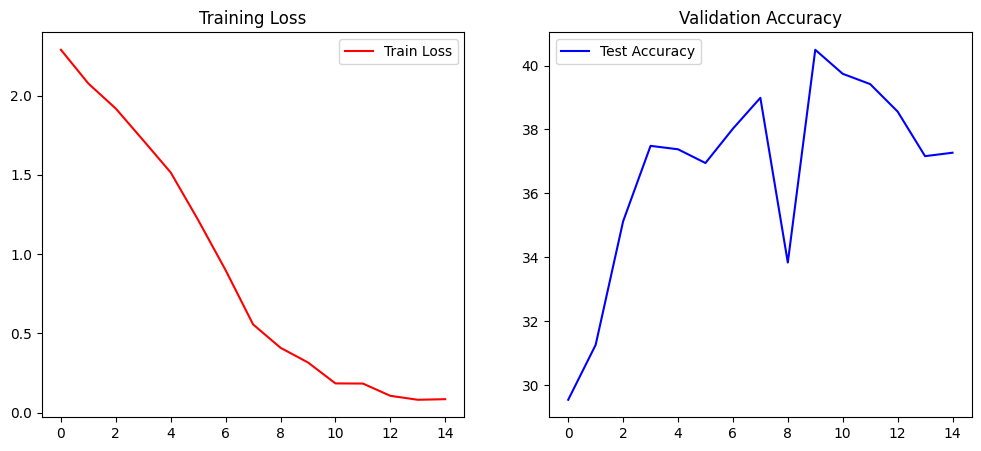

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


                       precision    recall  f1-score   support

    Happily surprised       0.59      0.49      0.54       156
    Happily disgusted       0.42      0.09      0.15        54
        Sadly fearful       0.08      0.19      0.11        26
          Sadly angry       0.19      0.16      0.17        50
      Sadly surprised       0.12      0.08      0.10        24
      Sadly disgusted       0.35      0.75      0.48       162
      Fearfully angry       0.28      0.25      0.26        32
  Fearfully surprised       0.54      0.30      0.39       138
  Fearfully disgusted       0.00      0.00      0.00         6
    Angrily surprised       0.23      0.07      0.11        42
    Angrily disgusted       0.39      0.37      0.38       201
Disgustedly surprised       0.20      0.06      0.10        32
      Happily fearful       0.00      0.00      0.00         4
          Happily sad       0.00      0.00      0.00         4

             accuracy                           0.37 

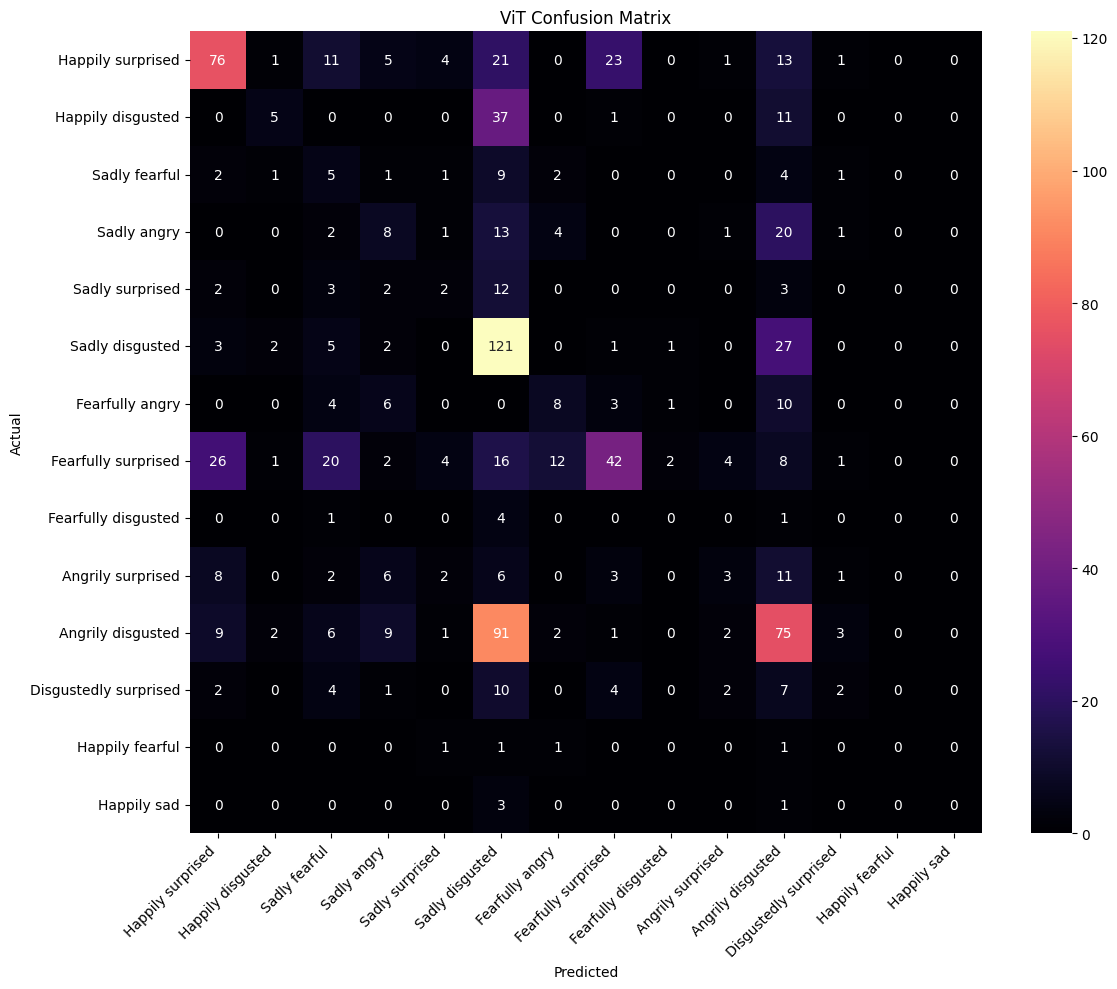

In [8]:
# Training curves
plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(history['train_loss'], label='Train Loss', color='red')
plt.title('Training Loss')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history['test_acc'], label='Test Accuracy', color='blue')
plt.title('Validation Accuracy')
plt.legend()
plt.savefig(os.path.join(OUTPUT_DIR, 'training_curves.png'))
plt.show()

# Confusion Matrix
model.eval()
all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(DEVICE), labels.to(DEVICE)
        outputs = model(images)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

print(classification_report(all_labels, all_preds, target_names=[EMO_MAP[i] for i in range(14)]))

cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='magma', 
            xticklabels=[EMO_MAP[i] for i in range(14)], 
            yticklabels=[EMO_MAP[i] for i in range(14)])
plt.title('ViT Confusion Matrix')
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'confusion_matrix.png'))
plt.show()